# Stage 2: MNIST Voting Ensemble

Project goal: use MNIST to compare individual classifiers with hard and soft voting ensembles. The notebook measures accuracy, macro F1, training time, and prediction time, then saves a results table and comparison figures when run.

Stage 1 remains a breast cancer sanity-check baseline. Stage 2 moves to MNIST, which is closer to the voting-ensemble exercise in the book and gives the models a larger, multiclass problem where ensemble behavior is easier to observe.

## Why MNIST for ensemble learning?

The breast cancer dataset is useful for checking that our project code works, but it is small and binary. MNIST has many more observations, 10 classes, and high-dimensional image features. That makes it more suitable for comparing individual classifiers with voting ensembles.

A voting ensemble only helps when its members are both relevant and diverse. If every classifier makes the same mistakes, voting will not add much. If the classifiers learn different useful patterns, voting can reduce variance and sometimes improve accuracy.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.datasets import fetch_openml
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Data split

Fast mode is the default so the notebook is practical on a laptop. To use the full book-style split, set `FAST_MODE = False`.

- Fast mode: 20,000 train, 5,000 validation, 10,000 test
- Full mode: 50,000 train, 10,000 validation, 10,000 test

In [2]:
FAST_MODE = True
RANDOM_STATE = 42

if FAST_MODE:
    N_TRAIN = 20_000
    N_VALIDATION = 5_000
    N_TEST = 10_000
else:
    N_TRAIN = 50_000
    N_VALIDATION = 10_000
    N_TEST = 10_000

In [3]:
def load_mnist_splits(n_train, n_validation, n_test, random_state=42):
    """Load MNIST and return train, validation, and test splits."""
    X, y = fetch_openml("mnist_784", version=1, as_frame=False, return_X_y=True)
    X = X.astype("float32") / 255.0
    y = y.astype("int64")

    total_size = n_train + n_validation + n_test
    if total_size < len(X):
        X, _, y, _ = train_test_split(
            X,
            y,
            train_size=total_size,
            random_state=random_state,
            stratify=y,
        )

    validation_and_train_size = n_train + n_validation
    X_train_valid, X_test, y_train_valid, y_test = train_test_split(
        X,
        y,
        train_size=validation_and_train_size,
        test_size=n_test,
        random_state=random_state,
        stratify=y,
    )

    validation_fraction = n_validation / validation_and_train_size
    X_train, X_validation, y_train, y_validation = train_test_split(
        X_train_valid,
        y_train_valid,
        test_size=validation_fraction,
        random_state=random_state,
        stratify=y_train_valid,
    )

    return X_train, X_validation, X_test, y_train, y_validation, y_test

In [4]:
X_train, X_validation, X_test, y_train, y_validation, y_test = load_mnist_splits(
    N_TRAIN,
    N_VALIDATION,
    N_TEST,
    random_state=RANDOM_STATE,
)

print(f"Train shape:      X={X_train.shape}, y={y_train.shape}")
print(f"Validation shape: X={X_validation.shape}, y={y_validation.shape}")
print(f"Test shape:       X={X_test.shape}, y={y_test.shape}")

Train shape:      X=(20000, 784), y=(20000,)
Validation shape: X=(5000, 784), y=(5000,)
Test shape:       X=(10000, 784), y=(10000,)


## Models

We compare a random forest, extremely randomized trees, a fast SVM-like linear classifier, and logistic regression. The SVM-like model uses `SGDClassifier` with hinge loss because a full kernel SVM would be computationally expensive on MNIST, especially in full mode.

Logistic regression is included because it provides class probabilities, which are useful for soft voting.

In [5]:
def make_individual_models(random_state=42):
    """Create the individual classifiers for the MNIST voting experiment."""
    return {
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            n_jobs=-1,
            random_state=random_state,
        ),
        "Extra-Trees": ExtraTreesClassifier(
            n_estimators=100,
            n_jobs=-1,
            random_state=random_state,
        ),
        "Linear SVM-like SGD": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "model",
                    SGDClassifier(
                        loss="hinge",
                        max_iter=1000,
                        tol=1e-3,
                        random_state=random_state,
                    ),
                ),
            ]
        ),
        "Logistic Regression": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=200,
                        n_jobs=-1,
                        random_state=random_state,
                    ),
                ),
            ]
        ),
    }


individual_models = make_individual_models(random_state=RANDOM_STATE)
individual_models

{'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Extra-Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'Linear SVM-like SGD': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', SGDClassifier(random_state=42))]),
 'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  LogisticRegression(max_iter=200, n_jobs=-1, random_state=42))])}

## Evaluation helpers

For each model, we record accuracy, macro F1, training time, validation prediction time, and test prediction time. Macro F1 gives every digit class equal weight, which is helpful for multiclass classification.

In [6]:
def evaluate_classifier(model_name, model, X_train, y_train, X_validation, y_validation, X_test, y_test):
    """Fit one classifier and evaluate it on validation and test sets."""
    fitted_model = clone(model)

    start = time.perf_counter()
    fitted_model.fit(X_train, y_train)
    training_time = time.perf_counter() - start

    start = time.perf_counter()
    validation_pred = fitted_model.predict(X_validation)
    validation_prediction_time = time.perf_counter() - start

    start = time.perf_counter()
    test_pred = fitted_model.predict(X_test)
    test_prediction_time = time.perf_counter() - start

    row = {
        "model": model_name,
        "accuracy_validation": accuracy_score(y_validation, validation_pred),
        "macro_f1_validation": f1_score(y_validation, validation_pred, average="macro"),
        "accuracy_test": accuracy_score(y_test, test_pred),
        "macro_f1_test": f1_score(y_test, test_pred, average="macro"),
        "training_time_seconds": training_time,
        "validation_prediction_time_seconds": validation_prediction_time,
        "test_prediction_time_seconds": test_prediction_time,
    }

    return row, fitted_model


def evaluate_predictions(model_name, validation_pred, test_pred, y_validation, y_test, validation_time, test_time):
    """Create a results row from predictions made by already fitted models."""
    return {
        "model": model_name,
        "accuracy_validation": accuracy_score(y_validation, validation_pred),
        "macro_f1_validation": f1_score(y_validation, validation_pred, average="macro"),
        "accuracy_test": accuracy_score(y_test, test_pred),
        "macro_f1_test": f1_score(y_test, test_pred, average="macro"),
        "training_time_seconds": 0.0,
        "validation_prediction_time_seconds": validation_time,
        "test_prediction_time_seconds": test_time,
    }

## Train individual classifiers

Each model is fit independently. The validation set helps us compare models before looking at the final test scores.

In [7]:
rows = []
fitted_individual_models = {}

for model_name, model in individual_models.items():
    print(f"Training {model_name}...")
    row, fitted_model = evaluate_classifier(
        model_name,
        model,
        X_train,
        y_train,
        X_validation,
        y_validation,
        X_test,
        y_test,
    )
    rows.append(row)
    fitted_individual_models[model_name] = fitted_model

individual_results = pd.DataFrame(rows).sort_values(
    by="accuracy_validation",
    ascending=False,
).reset_index(drop=True)

individual_results

Training Random Forest...
Training Extra-Trees...
Training Linear SVM-like SGD...
Training Logistic Regression...


,model,accuracy_validation,macro_f1_validation,accuracy_test,macro_f1_test,training_time_seconds,validation_prediction_time_seconds,test_prediction_time_seconds
0,Extra-Trees,0.9608,0.960429,0.9613,0.960954,3.687842,0.094551,0.204936
1,Random Forest,0.9570,0.956526,0.9572,0.956892,3.612077,0.093983,0.183251
2,Linear SVM-like SGD,0.9062,0.905238,0.9104,0.909668,109.204197,0.058471,0.112283
3,Logistic Regression,0.8882,0.886826,0.8923,0.891041,19.697514,0.073237,0.125838


## Hard voting versus soft voting

Hard voting predicts the class that receives the most votes from the member classifiers. Soft voting averages predicted class probabilities and picks the class with the highest average probability.

The voting rows below reuse the already fitted base models in `fitted_individual_models`. They do not retrain the base learners, so `training_time_seconds` is reported as `0.0` additional training time. Prediction time still includes the time needed to ask each fitted model for predictions or probabilities and combine those outputs.

Soft voting can work well when the probability estimates are meaningful, but it can only use models that implement `predict_proba`. The SVM-like SGD model does not provide probabilities in this configuration, so it is included in hard voting but not soft voting.

In [8]:
def manual_hard_vote(models, X):
    """Predict by majority vote from already fitted models."""
    predictions = np.array([model.predict(X) for model in models])
    return np.apply_along_axis(
        lambda votes: np.bincount(votes.astype(int)).argmax(),
        axis=0,
        arr=predictions,
    )


def manual_soft_vote(models, X):
    """Predict by averaging class probabilities from already fitted models."""
    probabilities = np.array([model.predict_proba(X) for model in models])
    mean_probabilities = probabilities.mean(axis=0)
    return mean_probabilities.argmax(axis=1)


hard_voting_model_names = [
    "Random Forest",
    "Extra-Trees",
    "Linear SVM-like SGD",
    "Logistic Regression",
]
soft_voting_model_names = [
    "Random Forest",
    "Extra-Trees",
    "Logistic Regression",
]

hard_voting_models = [fitted_individual_models[name] for name in hard_voting_model_names]
soft_voting_models = [fitted_individual_models[name] for name in soft_voting_model_names]

start = time.perf_counter()
hard_validation_pred = manual_hard_vote(hard_voting_models, X_validation)
hard_validation_time = time.perf_counter() - start

start = time.perf_counter()
hard_test_pred = manual_hard_vote(hard_voting_models, X_test)
hard_test_time = time.perf_counter() - start

rows.append(
    evaluate_predictions(
        "Hard Voting",
        hard_validation_pred,
        hard_test_pred,
        y_validation,
        y_test,
        hard_validation_time,
        hard_test_time,
    )
)

start = time.perf_counter()
soft_validation_pred = manual_soft_vote(soft_voting_models, X_validation)
soft_validation_time = time.perf_counter() - start

start = time.perf_counter()
soft_test_pred = manual_soft_vote(soft_voting_models, X_test)
soft_test_time = time.perf_counter() - start

rows.append(
    evaluate_predictions(
        "Soft Voting",
        soft_validation_pred,
        soft_test_pred,
        y_validation,
        y_test,
        soft_validation_time,
        soft_test_time,
    )
)

## Compare results

The table compares individual classifiers, hard voting, and soft voting. Remember that the best ensemble is not guaranteed to beat every individual model. Ensemble performance depends on the relevance of the base learners and the diversity of their errors.

In [9]:
results = pd.DataFrame(rows).sort_values(
    by="accuracy_validation",
    ascending=False,
).reset_index(drop=True)
results["test_error_rate"] = 1.0 - results["accuracy_test"]

results

,model,accuracy_validation,macro_f1_validation,accuracy_test,macro_f1_test,training_time_seconds,validation_prediction_time_seconds,test_prediction_time_seconds,test_error_rate
0,Extra-Trees,0.9608,0.960429,0.9613,0.960954,3.687842,0.094551,0.204936,0.0387
1,Random Forest,0.9570,0.956526,0.9572,0.956892,3.612077,0.093983,0.183251,0.0428
2,Hard Voting,0.9454,0.944624,0.9493,0.948822,0.000000,0.369458,0.727349,0.0507
3,Soft Voting,0.9338,0.932864,0.9347,0.933967,0.000000,0.246994,0.476598,0.0653
4,Linear SVM-like SGD,0.9062,0.905238,0.9104,0.909668,109.204197,0.058471,0.112283,0.0896
5,Logistic Regression,0.8882,0.886826,0.8923,0.891041,19.697514,0.073237,0.125838,0.1077


## Save outputs

Running this cell writes the requested CSV table and two comparison figures. The `results/` directory is created if it does not already exist.

The zoomed accuracy plot makes small accuracy differences visible. The horizontal test error-rate plot is often easier to read because lower error is better, and small differences near the top of the accuracy scale become easier to compare.

Project root: C:\Users\kuli1\ensemble-learning-lab
Tables directory: C:\Users\kuli1\ensemble-learning-lab\results\tables
Figures directory: C:\Users\kuli1\ensemble-learning-lab\results\figures
Saved table to C:\Users\kuli1\ensemble-learning-lab\results\tables\stage2_mnist_voting_results.csv
Saved zoomed accuracy figure to C:\Users\kuli1\ensemble-learning-lab\results\figures\stage2_mnist_accuracy_zoomed.png
Saved test error-rate figure to C:\Users\kuli1\ensemble-learning-lab\results\figures\stage2_mnist_test_error_rate.png


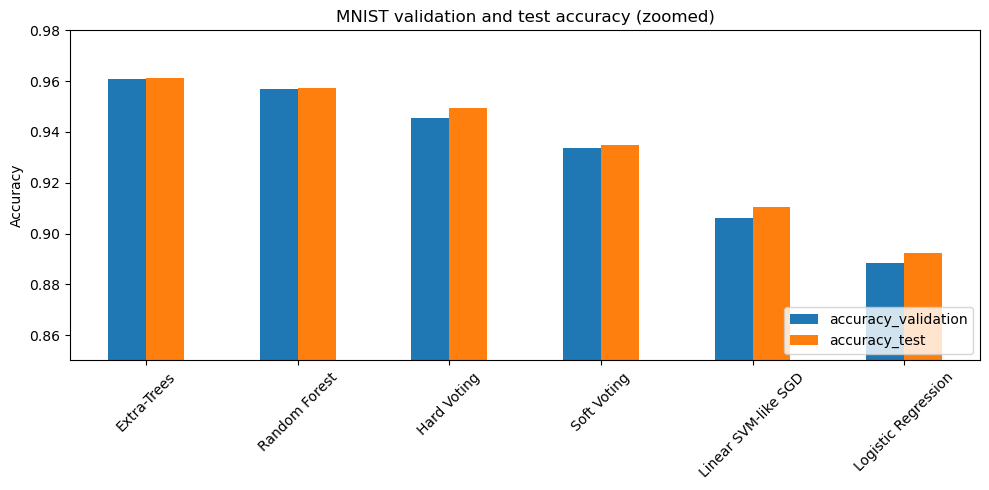

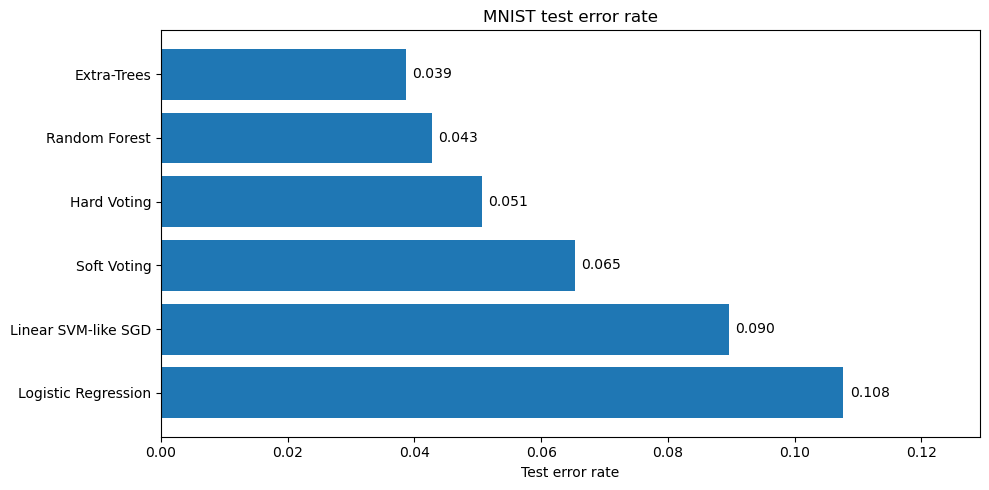

In [11]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Tables directory: {tables_dir}")
print(f"Figures directory: {figures_dir}")

csv_path = tables_dir / "stage2_mnist_voting_results.csv"
accuracy_figure_path = figures_dir / "stage2_mnist_accuracy_zoomed.png"
error_figure_path = figures_dir / "stage2_mnist_test_error_rate.png"

results.to_csv(csv_path, index=False)

plot_data = results.set_index("model")

fig, ax = plt.subplots(figsize=(10, 5))
plot_data[["accuracy_validation", "accuracy_test"]].plot(
    kind="bar",
    ax=ax,
)
ax.set_title("MNIST validation and test accuracy (zoomed)")
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
ax.set_ylim(0.85, 0.98)
ax.tick_params(axis="x", labelrotation=45)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(accuracy_figure_path, dpi=150, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(10, 5))
error_data = plot_data["test_error_rate"]
bars = ax.barh(error_data.index, error_data.values)
ax.invert_yaxis()
ax.set_title("MNIST test error rate")
ax.set_xlabel("Test error rate")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
    )

ax.set_xlim(0, max(error_data.max() * 1.20, 0.02))
fig.tight_layout()
fig.savefig(error_figure_path, dpi=150, bbox_inches="tight")

print(f"Saved table to {csv_path}")
print(f"Saved zoomed accuracy figure to {accuracy_figure_path}")
print(f"Saved test error-rate figure to {error_figure_path}")

### 
1. **Extra-Trees has the best validation accuracy.**  
   Its validation accuracy is about 0.9608, followed closely by Random Forest.

2. **Hard voting does not improve over the best individual classifier.**  
   Hard Voting has lower validation and test accuracy than Extra-Trees. This suggests that simply combining classifiers by majority vote is not enough to beat the strongest base learner.

3. **Soft voting does not improve over hard voting.**  
   Soft Voting performs worse than Hard Voting in this run. One possible reason is that the probability estimates from the weaker linear models are not accurate enough, so averaging probabilities can drag down the ensemble.

4. **The most expensive individual model to train is the Linear SVM-like SGD classifier.**  
   However, its accuracy is much lower than Extra-Trees and Random Forest, so the extra training cost is not worth it in this experiment. Extra-Trees gives the best accuracy with much shorter training time.

5. **The ensemble results do not suggest enough useful relevance and diversity among the base learners.**  
   Extra-Trees and Random Forest are strong, but the linear models are much weaker. Although they may be diverse, their errors are not complementary enough to improve voting. This shows that a successful ensemble needs base learners that are both individually relevant and complementary in their errors.